In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [2]:
# Set image size and batch size
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Dataset directories
train_dir = r"D:\Btech\Sem 2\ICTE\Dataset etp\archive\Train\Train"
val_dir   = r"D:\Btech\Sem 2\ICTE\Dataset etp\archive\Validation\Validation"
test_dir  = r"D:\Btech\Sem 2\ICTE\Dataset etp\archive\Test\Test"


In [3]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 150 images belonging to 3 classes.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')  # 3 output classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3),
        ModelCheckpoint('custom_cnn_plant_disease.h5', save_best_only=True)
    ]
)


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3851 - loss: 1.4445

42/42 ━━━━━━━━━━━━━━━━━━━━ 154s 4s/step - accuracy: 0.3868 - loss: 1.4372 - val_accuracy: 0.6667 - val_loss: 0.8334
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7339 - loss: 0.6401

42/42 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.7351 - loss: 0.6379 - val_accuracy: 0.7667 - val_loss: 0.4949
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8950 - loss: 0.3077

42/42 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.8949 - loss: 0.3081 - val_accuracy: 0.8167 - val_loss: 0.4827
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9169 - loss: 0.2760

42/42 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.9169 - loss: 0.2760 - val_accuracy: 0.8833 - val_loss: 0.3308
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.9516 - loss: 0.1685 - val_accuracy: 0.8500 - val_loss: 0.3988
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9532 - loss: 0.1532

42/42 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9531 - loss: 0.1535 - val_accuracy: 0.8667 - val_loss: 0.3240
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9702 - loss: 0.1295

42/42 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9701 - loss: 0.1290 - val_accuracy: 0.9000 - val_loss: 0.2290
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9631 - loss: 0.1494 - val_accuracy: 0.9167 - val_loss: 0.2684
Epoch 9/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.9639 - loss: 0.0929 - val_accuracy: 0.8000 - val_loss: 0.5216
Epoch 10/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9540 - loss: 0.1545 - val_accuracy: 0.9333 - val_loss: 0.2982


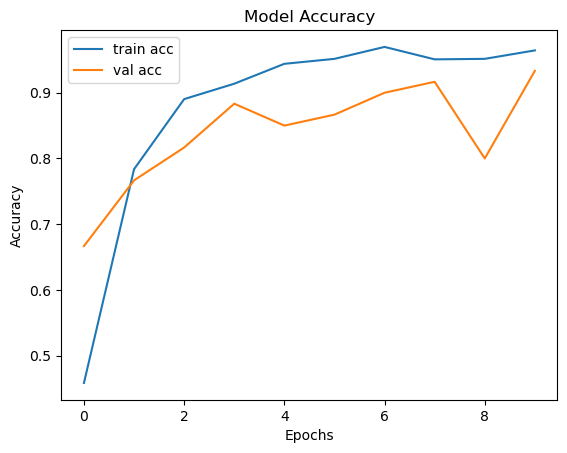

In [6]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()


In [8]:
# Save the model in the Keras format (.keras)
model.save('custom_cnn_plant_disease.keras')


In [9]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('custom_cnn_plant_disease.keras')


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9129 - loss: 0.2738
Test Accuracy: 90.67%
Test Loss: 0.3374


In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

# Class labels mapping
class_labels = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step
              precision    recall  f1-score   support

     Healthy       0.88      0.90      0.89        50
     Powdery       0.86      0.96      0.91        50
        Rust       1.00      0.86      0.92        50

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150



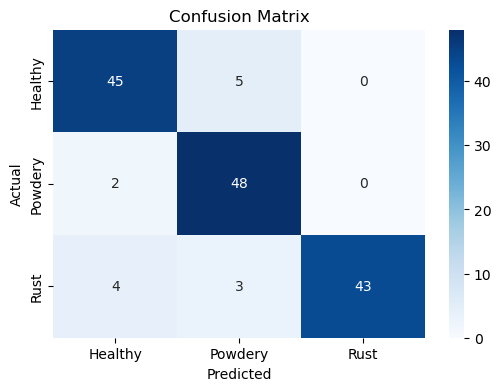

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [2]:
import time
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import os

# Load the model
model = load_model("custom_cnn_plant_disease.keras")

# Define the test directories
test_healthy_path = "D:/Btech/Sem 2/ICTE/Dataset etp/archive/Test/Test/Healthy"
test_powdery_path = "D:/Btech/Sem 2/ICTE/Dataset etp/archive/Test/Test/Powdery"
test_rust_path = "D:/Btech/Sem 2/ICTE/Dataset etp/archive/Test/Test/Rust"

# Define class names
class_names = ['Healthy', 'Powdery', 'Rust']

# Function to preprocess the image and make a prediction
def preprocess_and_predict(image_path):
    image = load_img(image_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image / 255.0  # Normalize the image
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    prediction = model.predict(image)
    return np.argmax(prediction)

# Create a list of image paths and corresponding labels
image_paths = []
true_labels = []

# Collect images and labels from the test set
for label, category in enumerate(class_names):
    category_path = globals()[f"test_{category.lower()}_path"]
    for image_name in os.listdir(category_path):
        if image_name.endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(category_path, image_name))
            true_labels.append(label)

# Start timing the preprocessing and prediction
start_time = time.time()

# Make predictions
predicted_labels = []
for image_path in image_paths:
    predicted_label = preprocess_and_predict(image_path)
    predicted_labels.append(predicted_label)

# Calculate time taken for preprocessing and prediction
end_time = time.time()
preprocess_time = end_time - start_time

# Convert lists to numpy arrays for easier evaluation
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Calculate metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')
f1 = f1_score(true_labels, predicted_labels, average='weighted')

# Display results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")
print(f"Preprocessing and Prediction Time: {preprocess_time:.2f} seconds")


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━